Research Topic:

Supervised

Regression: Does regression perform better if applied separately for casual and registered riders

Unsupervised:

Classification: Does the clusters describe 

### Import necessary libraries

In [58]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

#### Load the dataset

In [59]:
data = pd.read_csv(os.path.join(
    "data", "bike_sharing_hourly.csv"
))

display(data.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,high_demand
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Low
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Low
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Low
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Low
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Low


### Preprocessing

In [60]:
target_columns = ["casual", "registered", "cnt", "high_demand"]


In [61]:
# change high_demand to binary variable
data["high_demand"] = data['high_demand'].map({'Low': 0, 'High': 1})

In [62]:
display(data[target_columns].head())

,casual,registered,cnt,high_demand
0,3,13,16,0
1,8,32,40,0
2,5,27,32,0
3,3,10,13,0
4,0,1,1,0


In [63]:
# Drop instant and dteday columns as they are not useful for modeling
data.drop(columns=["instant", "dteday"], inplace=True)

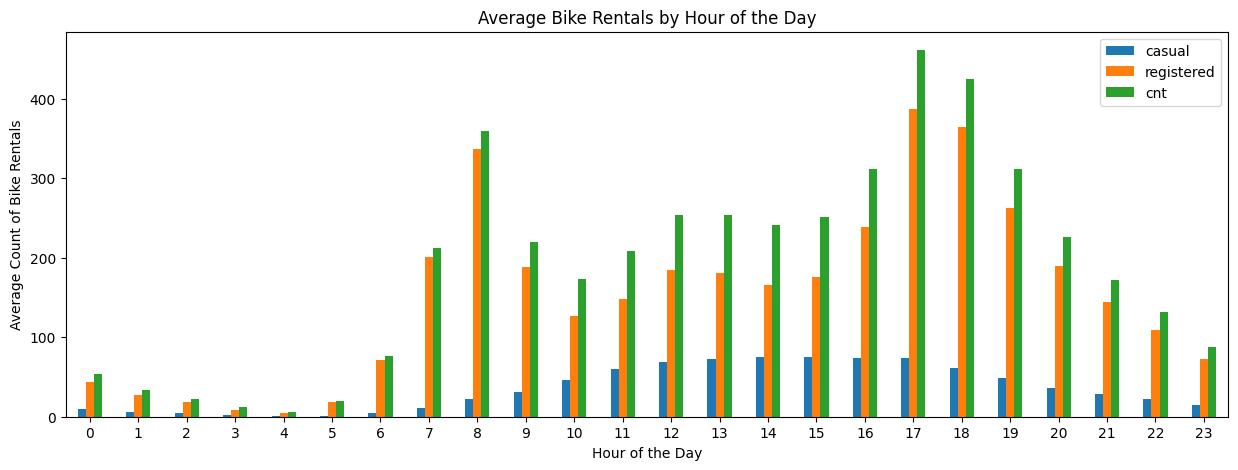

In [66]:
# display hourly distribution of bike rentals - casual, registered, and total
data.groupby("hr")[["casual", "registered", "cnt"]].mean().plot(kind="bar", figsize=(15, 5))

plt.title("Average Bike Rentals by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Count of Bike Rentals")
plt.xticks(rotation=0)
plt.show()

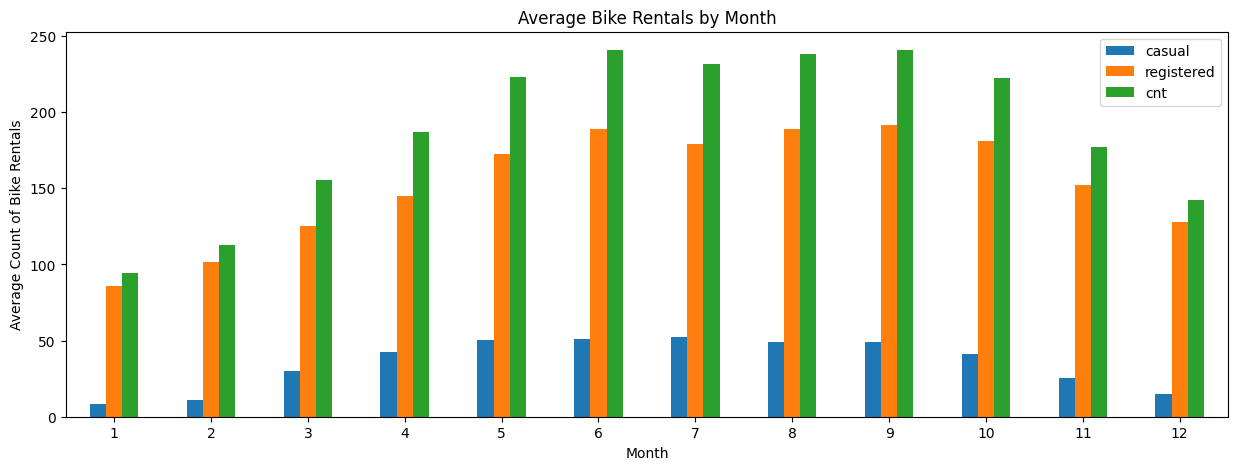

In [67]:
# display monthly distribution of bike rentals - casual, registered, and total
data.groupby("mnth")[["casual", "registered", "cnt"]].mean().plot(kind="bar", figsize=(15, 5))
plt.title("Average Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Count of Bike Rentals")
plt.xticks(rotation=0)
plt.show()

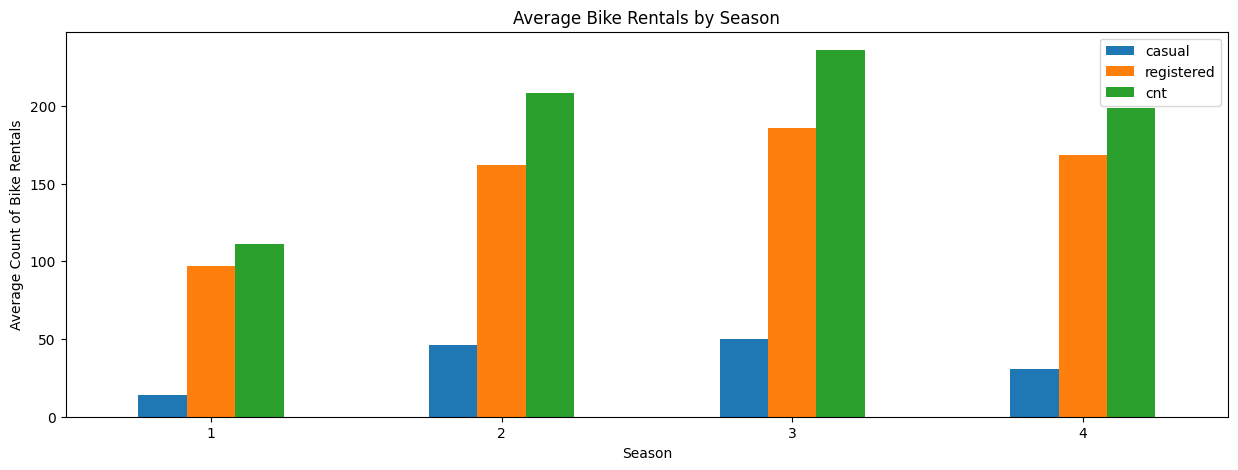

In [68]:
 # display seasonal distribution of bike rentals - casual, registered, and total
data.groupby("season")[["casual", "registered", "cnt"]].mean().plot(kind="bar", figsize=(15, 5))
plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Count of Bike Rentals")
plt.xticks(rotation=0)
plt.show()

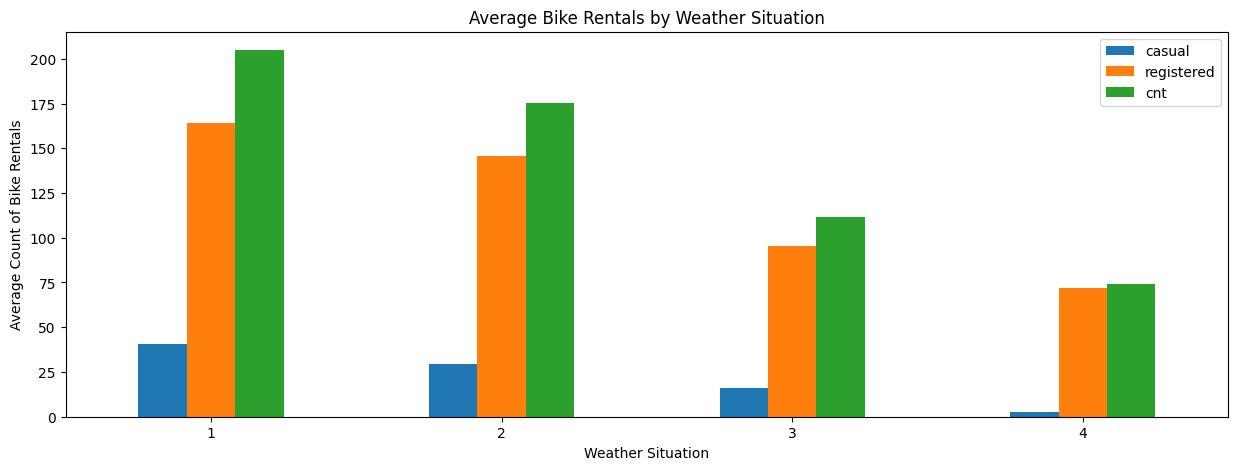

In [69]:
# display weathersit distribution of bike rentals - casual, registered, and total
data.groupby("weathersit")[["casual", "registered", "cnt"]].mean().plot(kind="bar", figsize=(15, 5))
plt.title("Average Bike Rentals by Weather Situation")
plt.xlabel("Weather Situation")
plt.ylabel("Average Count of Bike Rentals")
plt.xticks(rotation=0)
plt.show()

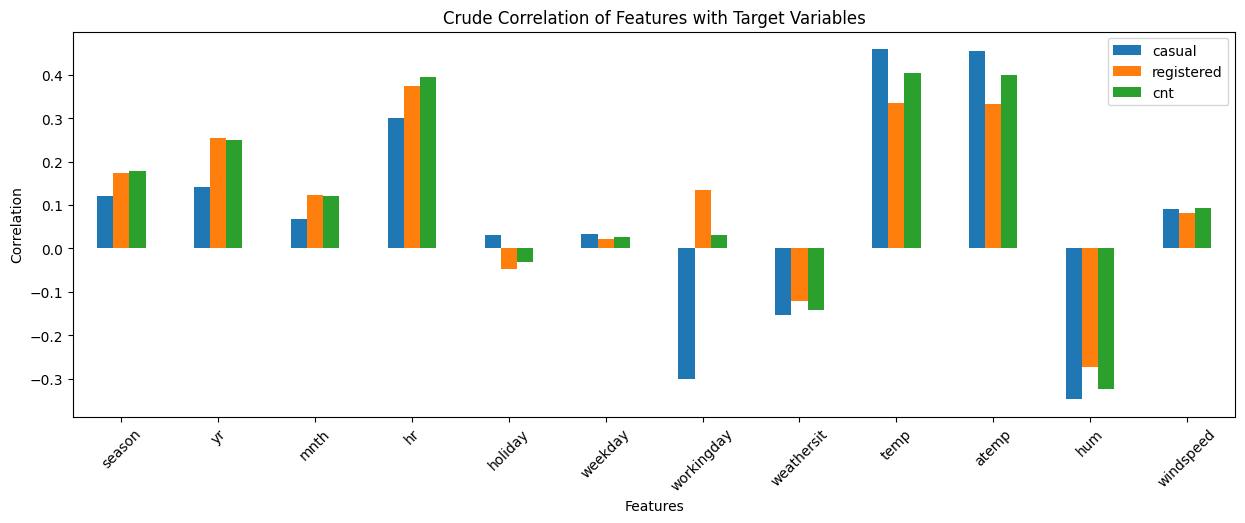

In [71]:
# crude correlation of features with target variables
data.corr()[target_columns[:-1]].loc[~data.columns.isin(target_columns)].plot(kind="bar", figsize=(15, 5))
plt.title("Crude Correlation of Features with Target Variables")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

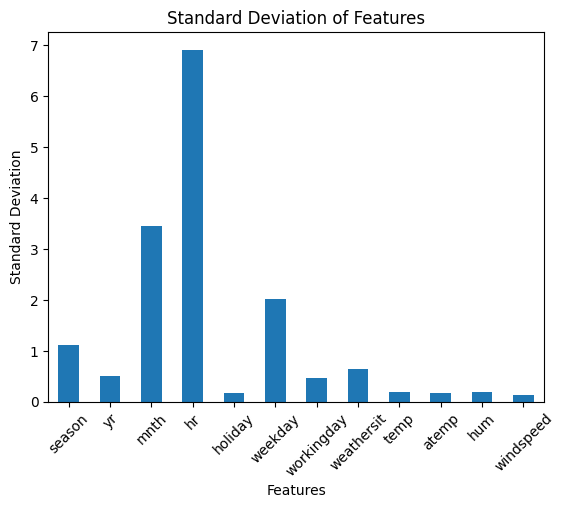

In [72]:
# plot the std of all the features
data.loc[:, ~data.columns.isin(target_columns)].std().plot(kind="bar")
plt.title("Standard Deviation of Features")
plt.xlabel("Features")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=45)
plt.show()

In [73]:
# Change workingday to is_weekend and holiday as they are more intuitive and useful for modeling
data['is_weekend'] = data['weekday'].isin([0, 6]).astype(int)

# Create one-hot encoding for categorical features with more than 2 categories and no clear cyclical features
data = pd.get_dummies(data, columns=["season", "weathersit", "mnth", "weekday"])

# drop one category to avoid multicollinearity
columns_to_drop = ["season_1", "weathersit_1", "mnth_1", "weekday_0"]

# Create cyclical features for hr column
data['hr_sin'] = np.sin(2 * np.pi * data['hr'] / 24)
data['hr_cos'] = np.cos(2 * np.pi * data['hr'] / 24)

# Drop hr and workingday columns as they are now represented by the new features
data.drop(columns=["hr", "workingday"], inplace=True)

# keep target columns at the end of the dataframe
data = data.reindex(columns=[col for col in data.columns if col not in target_columns] + target_columns)

# Numerical features are already min-max scaled / normalized, so we can directly use them for modeling

display(data.head())

,yr,holiday,temp,atemp,hum,windspeed,is_weekend,season_1,season_2,season_3,...,weekday_3,weekday_4,weekday_5,weekday_6,hr_sin,hr_cos,casual,registered,cnt,high_demand
0,0,0,0.24,0.2879,0.81,0.0,1,True,False,False,...,False,False,False,True,0.000000,1.000000,3,13,16,0
1,0,0,0.22,0.2727,0.80,0.0,1,True,False,False,...,False,False,False,True,0.258819,0.965926,8,32,40,0
2,0,0,0.22,0.2727,0.80,0.0,1,True,False,False,...,False,False,False,True,0.500000,0.866025,5,27,32,0
3,0,0,0.24,0.2879,0.75,0.0,1,True,False,False,...,False,False,False,True,0.707107,0.707107,3,10,13,0
4,0,0,0.24,0.2879,0.75,0.0,1,True,False,False,...,False,False,False,True,0.866025,0.500000,0,1,1,0


<Axes: >

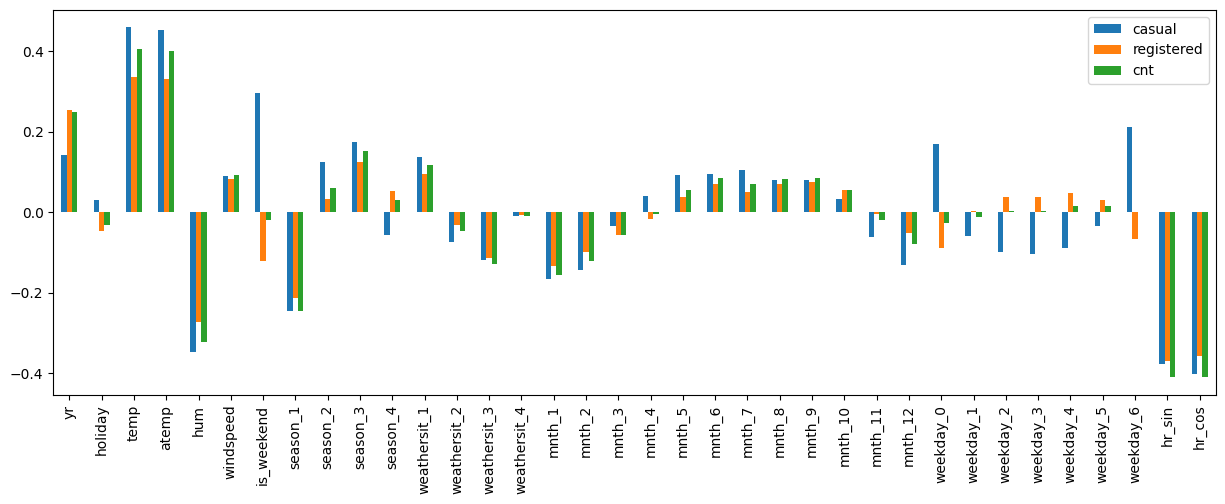

In [74]:
# correlation of features with target variables
data.corr()[target_columns[:-1]].loc[~data.columns.isin(target_columns)].plot(kind="bar", figsize=(15, 5))

In [75]:
data.drop(columns=columns_to_drop, inplace=True)

### Unsupervised

In [18]:
features = data.drop(columns=target_columns)
targets = data[target_columns]

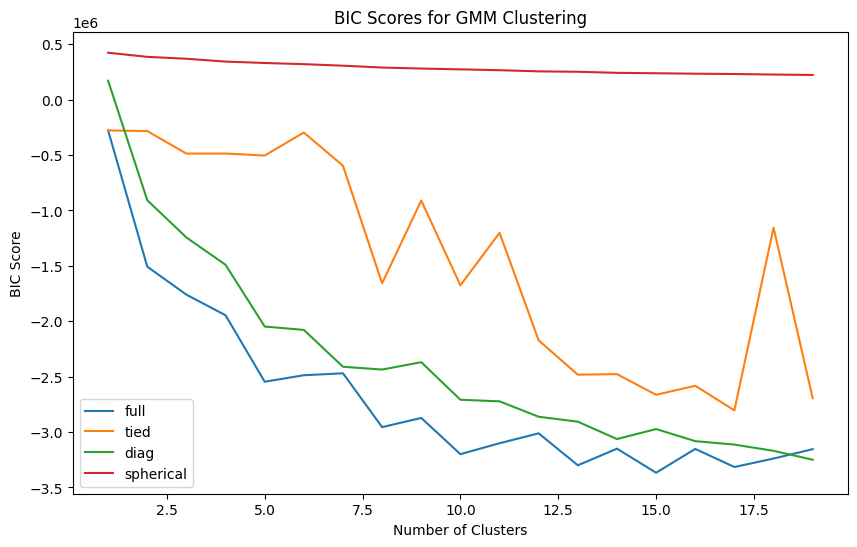

covariance_type              full
n_components                   15
BIC               -3367358.639591
Name: 14, dtype: object


In [ ]:
# perform GMM clustering in a similar fashion to Mclust in R
# determine the optimal number of clusters using BIC and the covariance structure
from sklearn.mixture import GaussianMixture
results = []
covariance_types = ['full', 'tied', 'diag', 'spherical']
n_components_range = range(1, 20)
for cov_type in covariance_types:
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type=cov_type, random_state=42)
        gmm.fit(features)
        results.append({
            'covariance_type': cov_type,
            'n_components': n_components,
            'BIC': gmm.bic(features)
        })

# plot the BIC scores for each covariance type and number of clusters
plt.figure(figsize=(10, 6))
for cov_type in covariance_types:
    subset = [r for r in results if r['covariance_type'] == cov_type]
    plt.plot([r['n_components'] for r in subset], [r['BIC'] for r in subset], label=cov_type)
plt.xlabel('Number of Clusters')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM Clustering')
plt.legend()
plt.show()

results_df = pd.DataFrame(results)
best = results_df.loc[results_df['BIC'].idxmin()]
print(best)

In [20]:
# Determine the average values of target variables for each cluster
best_gmm = GaussianMixture(n_components=best['n_components'], covariance_type=best['covariance_type'], random_state=42)
clusters = best_gmm.fit_predict(features)
data['cluster'] = clusters
cluster_means = data.groupby('cluster')[target_columns[:-1]].mean()
print(cluster_means)

            casual  registered         cnt
cluster                                   
0        13.756831  142.775956  156.532787
1        31.316000  110.512000  141.828000
2        15.043046   94.211921  109.254967
3        16.332096   86.979592  103.311688
4        51.014386  186.926790  237.941176
5        10.229242  107.690433  117.919675
6        48.911111  162.940741  211.851852
7        28.553971  154.460285  183.014257
8        35.110036  174.309553  209.419589
9        21.424714  178.092471  199.517185
10       52.938534  108.085106  161.023641
11       48.437198  196.066425  244.503623
12       51.961151  169.767626  221.728777
13       36.319815  180.683662  217.003476
14       55.775769  140.781193  196.556962


### Supervised: Elastic Net Regression

In [76]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, r2_score

In [77]:
# Perform elastic net regression to predict the target variable "casual" using the features using cross validation to determine the optimal alpha and l1_ratio parameters
# Name the pipeline 'pipeline_casual'
X_train, X_test, y_train_casual, y_test_casual = train_test_split(features, targets['casual'], test_size=0.2, random_state=42)
pipeline_casual = make_pipeline(StandardScaler(), ElasticNetCV(cv=5, random_state=42))
pipeline_casual.fit(X_train, y_train_casual)
print("Best alpha:", pipeline_casual.named_steps['elasticnetcv'].alpha_)
print("Best l1_ratio:", pipeline_casual.named_steps['elasticnetcv'].l1_ratio_)

# Test set performance
y_pred_casual = pipeline_casual.predict(X_test)
print("Test MSE:", mean_squared_error(y_test_casual, y_pred_casual))
print("Test R^2:", r2_score(y_test_casual, y_pred_casual))


Best alpha: 0.04565671497245206
Best l1_ratio: 0.5
Test MSE: 953.6658380151238
Test R^2: 0.5849682346146279


In [78]:
# Perform elastic net regression to predict the target variable "registered" using the features using cross validation to determine the optimal alpha and l1_ratio parameters
# Name the pipeline 'pipeline_registered'
X_train, X_test, y_train_registered, y_test_registered = train_test_split(features, targets['registered'], test_size=0.2, random_state=42)
pipeline_registered = make_pipeline(StandardScaler(), ElasticNetCV(cv=5, random_state=42))
pipeline_registered.fit(X_train, y_train_registered)
print("Best alpha:", pipeline_registered.named_steps['elasticnetcv'].alpha_)
print("Best l1_ratio:", pipeline_registered.named_steps['elasticnetcv'].l1_ratio_)

# Test set performance
y_pred_registered = pipeline_registered.predict(X_test)
print("Test MSE:", mean_squared_error(y_test_registered, y_pred_registered))
print("Test R^2:", r2_score(y_test_registered, y_pred_registered))

Best alpha: 0.11065376281318254
Best l1_ratio: 0.5
Test MSE: 12748.729119322194
Test R^2: 0.42245947221939717


In [79]:
# Perform elastic net regression to predict the target variable "cnt" using the features using cross validation to determine the optimal alpha and l1_ratio parameters
# Name the pipeline 'pipeline_cnt'
X_train, X_test, y_train_cnt, y_test_cnt = train_test_split(features, targets['cnt'], test_size=0.2, random_state=42)
pipeline_cnt = make_pipeline(StandardScaler(), ElasticNetCV(cv=5, random_state=42))
pipeline_cnt.fit(X_train, y_train_cnt)
print("Best alpha:", pipeline_cnt.named_steps['elasticnetcv'].alpha_)
print("Best l1_ratio:", pipeline_cnt.named_steps['elasticnetcv'].l1_ratio_)

# Test set performance
y_pred_cnt = pipeline_cnt.predict(X_test)
print("Test MSE:", mean_squared_error(y_test_cnt, y_pred_cnt))
print("Test R^2:", r2_score(y_test_cnt, y_pred_cnt))

Best alpha: 0.14991961278032895
Best l1_ratio: 0.5
Test MSE: 15515.655078993956
Test R^2: 0.5100125207869757


In [80]:
# Test combinations of elasticnet models for 'casual' and 'registered' as compared to 'cnt' to see if we can improve performance by modeling them separately

# Test set performance of the combined model
y_pred_combined = pipeline_casual.predict(X_test) + pipeline_registered.predict(X_test)
print("Test MSE:", mean_squared_error(y_test_cnt, y_pred_combined))
print("Test R^2:", r2_score(y_test_cnt, y_pred_combined))


Test MSE: 15478.529085831742
Test R^2: 0.5111849670491679


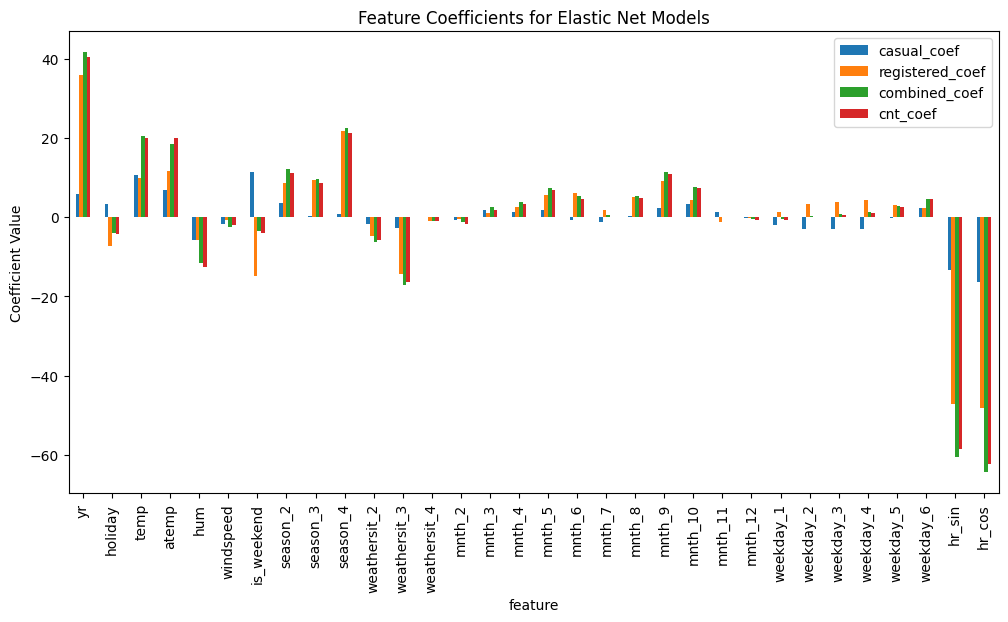

In [81]:
# Show visualization of feature importance for the three models by plotting the coefficients of the features for each model
feature_names = features.columns
coefficients_casual = pipeline_casual.named_steps['elasticnetcv'].coef_
coefficients_registered = pipeline_registered.named_steps['elasticnetcv'].coef_
coefficients_combined = coefficients_casual + coefficients_registered
coefficients_cnt = pipeline_cnt.named_steps['elasticnetcv'].coef_
coef_df = pd.DataFrame({
    'feature': feature_names,
    'casual_coef': coefficients_casual,
    'registered_coef': coefficients_registered,
    'combined_coef': coefficients_combined,
    'cnt_coef': coefficients_cnt
})

coef_df.set_index('feature', inplace=True)
coef_df.plot(kind='bar', figsize=(12, 6))
plt.title('Feature Coefficients for Elastic Net Models')
plt.ylabel('Coefficient Value')
plt.show()